In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime
import os
style.use('fast')
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score  
from statistics import mean

def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        plt.rc('xtick', labelsize=22)    
        plt.rc('ytick', labelsize=22)    
        plt.rcParams["font.family"] = "serif"
    
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [0, 1], 'k--',  lw=2.8)
        plt.plot(fpr, tpr, lw=2.8, color=color_ROC,label='Area = {:.3f}'.format(AUC_ROC))
        plt.fill_between(fpr, tpr,color=color_ROC, alpha=0.28)
        plt.xlabel('False positive rate',family="serif",fontsize = 26)
        plt.ylabel('True positive rate',family="serif",fontsize = 26)
        plt.title(f'ROC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/ROC_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [1, 0], 'k--',  lw=2.8)
        plt.plot(recall, precision, lw=2.8, color=color_PR,label='Area = {:.3f}'.format(AUC_PR))
        plt.fill_between(recall, precision,color=color_PR, alpha=0.28)
        plt.xlabel('Recall',family="serif",fontsize = 26)
        plt.ylabel('Precision',family="serif",fontsize = 26)
        plt.title(f'PRC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/PR_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
    
    return AUC_ROC, AUC_PR

# Analysis rankings

In [2]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
Nodes = [10,20,50,100]
In_degree = [2]
         
Algorithm = ["SWING", "dynGENIE3"]
ranking = {}

for nodes in Nodes:
   
    for degree in In_degree:
            
        for algorithm in Algorithm:
            
            ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"] = []
            ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"] = []
            
            for instance in range(100):
        
                instance = instance + 1
            
                if algorithm == "SWING":    
                                                            
                    mean_importance_file_SWING = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t").sort_values(by=["regulator-target"])
                    mean_importance_file_SWING_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t").sort_values(by=["regulator-target"])
                    
                    ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"].append(mean_importance_file_SWING["mean_importance"].values.tolist())
                    ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"].append(mean_importance_file_SWING_rand["mean_importance"].values.tolist())
                    
                else:
                    
                    mean_importance_file_dynGENIE3= pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
                    mean_importance_file_dynGENIE3_rand = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/networks_in_out_degree_{degree}_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list).sort_values(by=["Cause Gene", "Effect Gene"])
                    
                    ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"].append(mean_importance_file_dynGENIE3["mean_importance"].values.tolist())
                    ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"].append(mean_importance_file_dynGENIE3_rand["mean_importance"].values.tolist())
                    

## SWING 2 in-out

(0.0, 0.08)

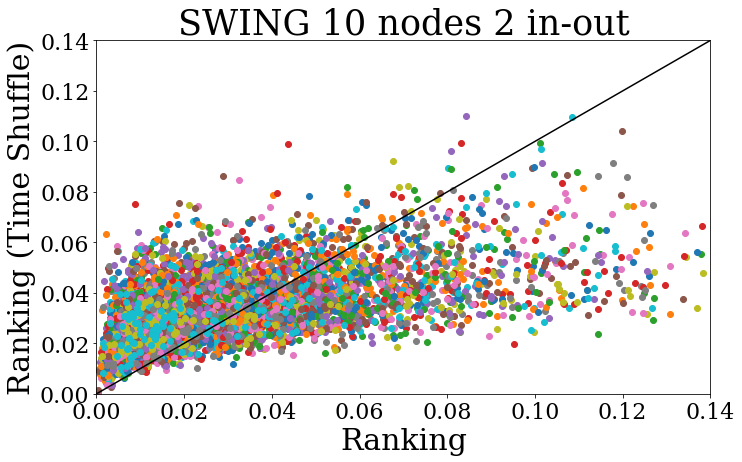

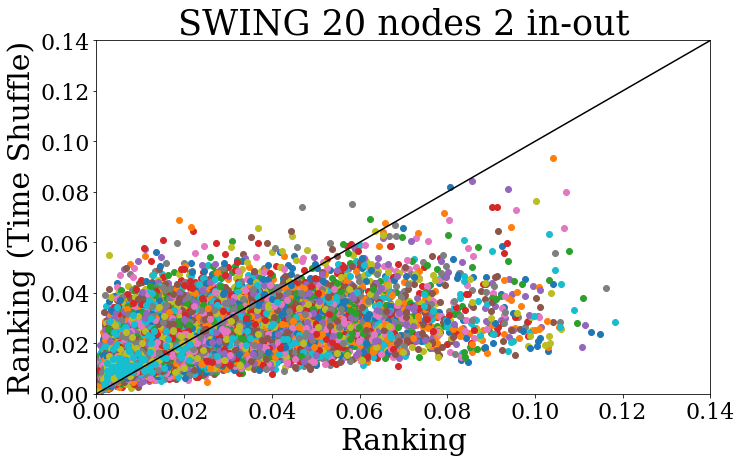

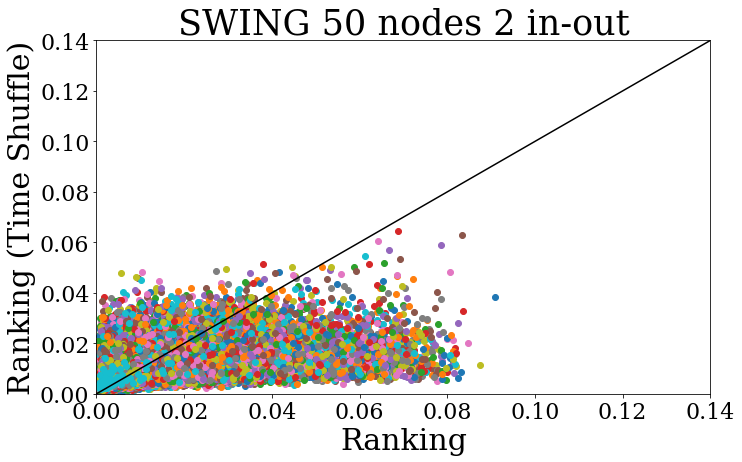

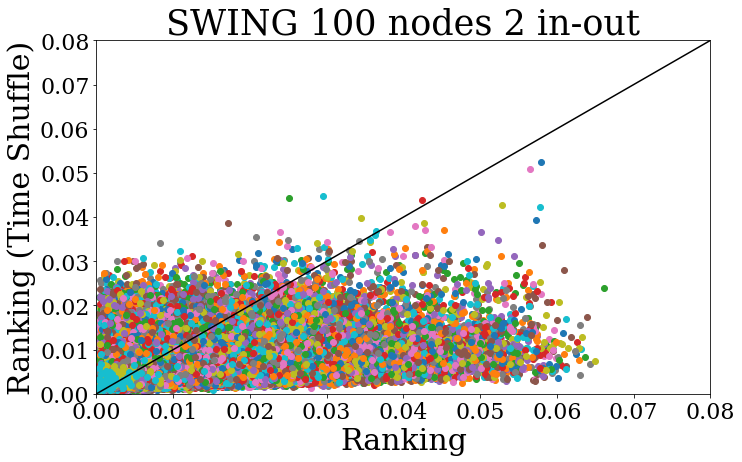

In [27]:
plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
x = np.arange(0,0.4,0.01)
y =x
file_path_data = "C:/Users/ivana/OneDrive/Desktop/Imagenes Internship"
algorithm = "SWING"
degree = 2

nodes = 10
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.14)
plt.ylim(0,0.14)

nodes = 20
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.14)
plt.ylim(0,0.14)

nodes = 50
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.14)
plt.ylim(0,0.14)

nodes = 100
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.08)
plt.ylim(0,0.08)
plt.savefig(f"{file_path_data}/ranking_rankingrand_SWING_{nodes}genes_{degree}degree.png", bbox_inches="tight", dpi=100 )


# dynGENIE3 2 in-out

(0.0, 0.16)

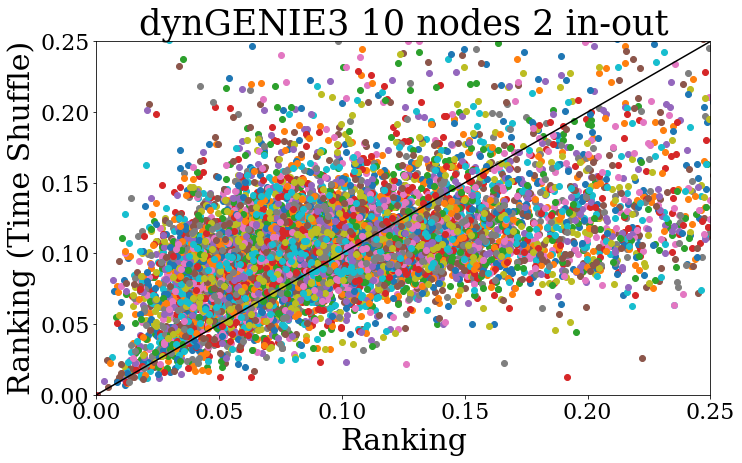

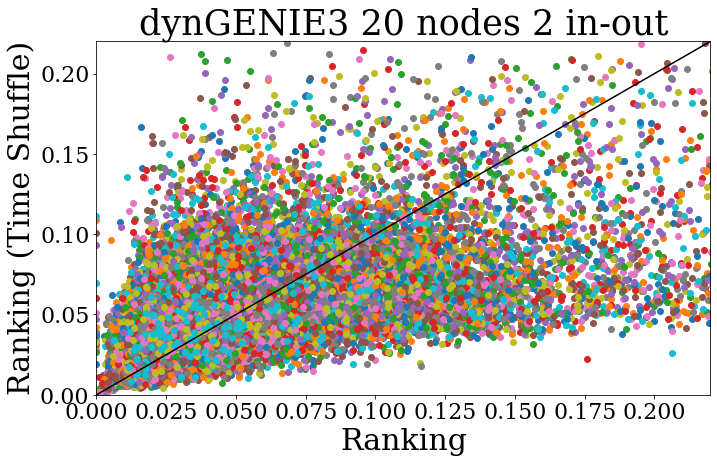

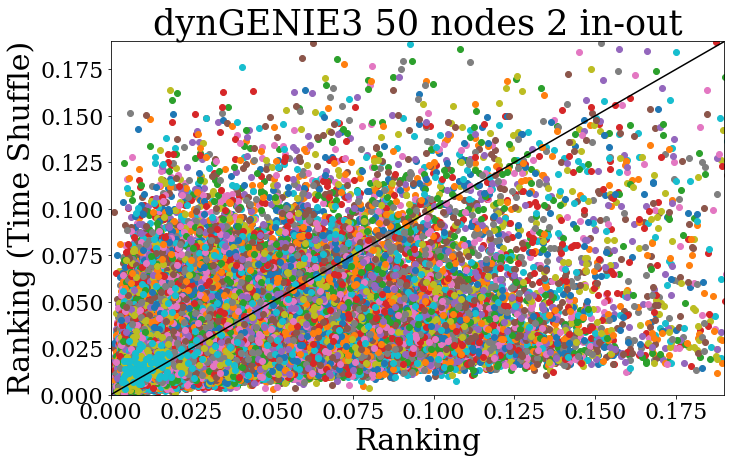

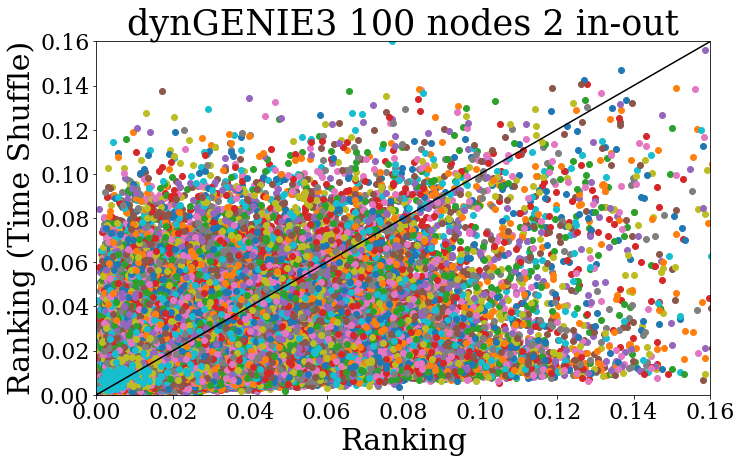

In [28]:
plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
x = np.arange(0,0.4,0.01)
y =x

algorithm = "dynGENIE3"
degree = 2

nodes = 10
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.25)
plt.ylim(0,0.25)

nodes = 20
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.22)
plt.ylim(0,0.22)

nodes = 50
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.19)
plt.ylim(0,0.19)

nodes = 100
plt.figure(figsize=(11,6.5))
plt.plot(ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree"], ranking[f"{algorithm}_{nodes}Nodes_{degree}Degree_rand"], 'o')
plt.plot(x,y,color = "k")
plt.xlabel("Ranking", fontsize = 30)
plt.ylabel("Ranking (Time Shuffle)", fontsize = 30)
plt.title(f"{algorithm} {nodes} nodes {degree} in-out", fontsize = 35)
plt.xlim(0,0.16)
plt.ylim(0,0.16)
plt.savefig(f"{file_path_data}/ranking_rankingrand_dynGENIE3_{nodes}genes_{degree}degree.png", bbox_inches="tight", dpi=100 )


# Analysis Threshold

## SWING 2 in-out

(0.0, 0.15)

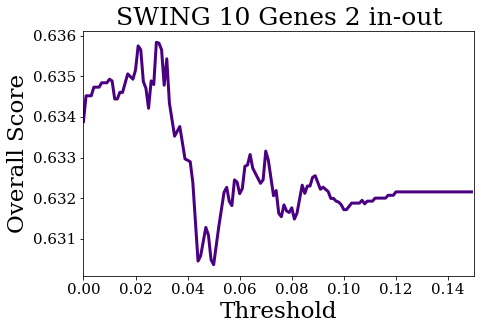

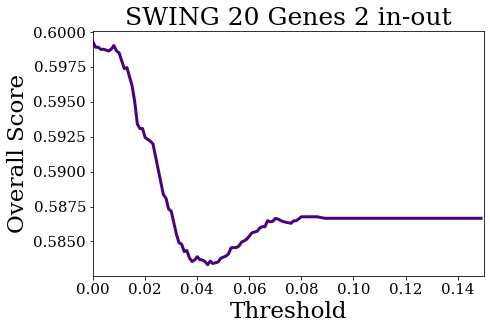

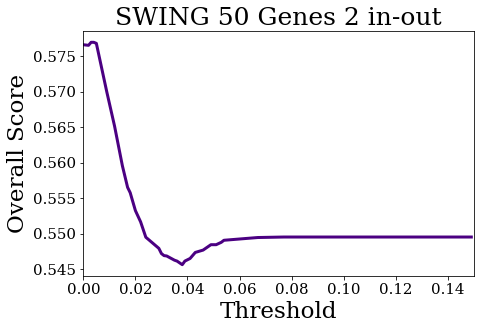

In [25]:
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

algorithm = "SWING"
degree = 2
Threshold = np.arange(0,0.15,0.001)

nodes = 10
values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
figure = plt.figure(figsize=(7,4.5))
plt.plot(Threshold, values_threshold["Value"], '-', color = "indigo", lw = 3)
plt.xlabel('Threshold', fontsize = 23)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
plt.xlim(0,0.15)

nodes = 20
values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
figure = plt.figure(figsize=(7,4.5))
plt.plot(Threshold, values_threshold["Value"], '-', color = "indigo", lw = 3)
plt.xlabel('Threshold', fontsize = 23)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
plt.xlim(0,0.15)

nodes = 50
values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
figure = plt.figure(figsize=(7,4.5))
plt.plot(Threshold, values_threshold["Value"], '-', color = "indigo", lw = 3)
plt.xlabel('Threshold', fontsize = 23)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
plt.xlim(0,0.15)

#nodes = 100
#values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
#figure = plt.figure(figsize=(7,4.5))
#plt.plot(Threshold, values_threshold["Value"], '-', color = "indigo", lw = 3)
#plt.xlabel('Threshold', fontsize = 23)
#plt.ylabel('Overall Score', fontsize = 23)
#plt.title(f"{algorithm} {nodes} Genes {degree} in-out degree", fontsize = 25)
#plt.xlim(0,0.15)

## dynGENIE3 2 in-out

(0.0, 0.15)

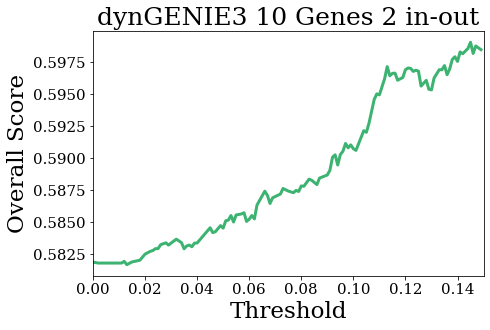

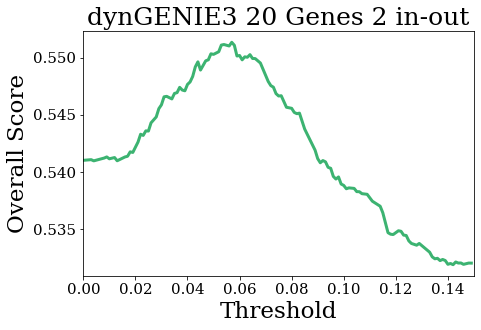

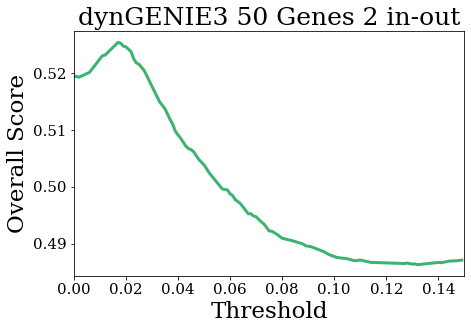

In [26]:
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

algorithm = "dynGENIE3"
degree = 2
Threshold = np.arange(0,0.15,0.001)

nodes = 10
values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
figure = plt.figure(figsize=(7,4.5))
plt.plot(Threshold, values_threshold["Value"], '-', color = "mediumseagreen", lw = 3)
plt.xlabel('Threshold', fontsize = 23)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
plt.xlim(0,0.15)

nodes = 20
values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
figure = plt.figure(figsize=(7,4.5))
plt.plot(Threshold, values_threshold["Value"], '-', color = "mediumseagreen", lw = 3)
plt.xlabel('Threshold', fontsize = 23)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
plt.xlim(0,0.15)

nodes = 50
values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
figure = plt.figure(figsize=(7,4.5))
plt.plot(Threshold, values_threshold["Value"], '-', color = "mediumseagreen", lw = 3)
plt.xlabel('Threshold', fontsize = 23)
plt.ylabel('Overall Score', fontsize = 23)
plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
plt.xlim(0,0.15)

#nodes = 100
#values_threshold = pd.read_csv(f"Values_Threshold_{degree}_in_degree/values_threshold_{degree}_{nodes}_{algorithm}.txt", sep = "\t", names = ["Value"])
#figure = plt.figure(figsize=(7,4.5))
#plt.plot(Threshold, values_threshold["Value"], '-', color = "mediumseagreen", lw = 3)
#plt.xlabel('Threshold', fontsize = 23)
#plt.ylabel('Overall Score', fontsize = 23)
#plt.title(f"{algorithm} {nodes} Genes {degree} in-out", fontsize = 25)
#plt.xlim(0,0.15)